## binagem de 60 segundos

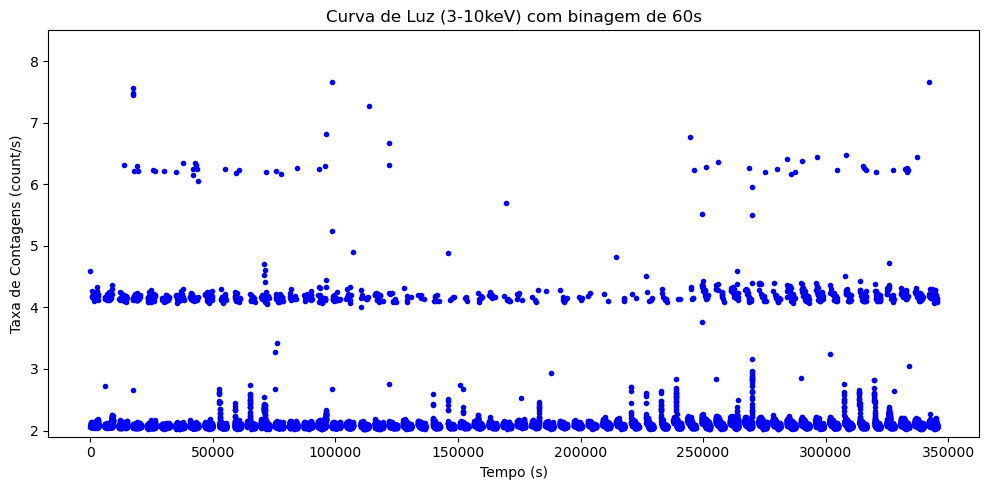

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

caminho = 'data/ bins 60s/3-10kev/nu30201034002A01_sr.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10keV) com binagem de 60s')
plt.ylim(1.9,8.5)


plt.tight_layout()
plt.show()

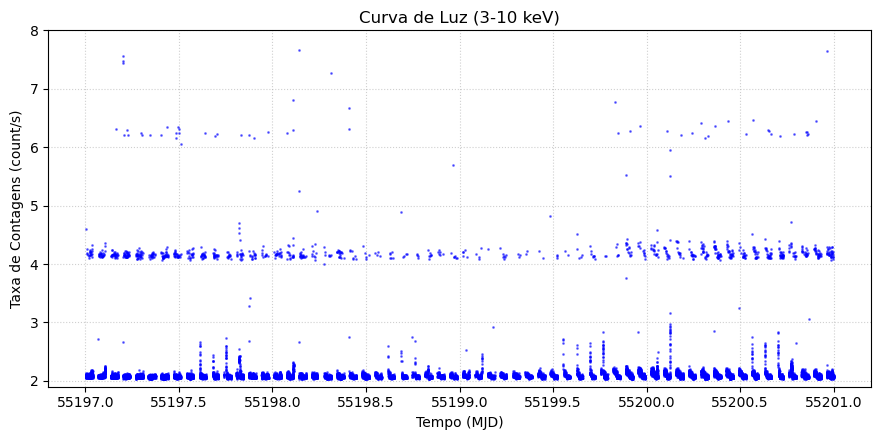

In [17]:
import matplotlib.pyplot as plt
from astropy.table import Table

caminho = 'data/ bins 60s/3-10kev/nu30201034002A01_sr.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

plt.figure(figsize=(9, 4.5))
plt.plot(df['MJD'], df['RATE'], 'b.', alpha=0.5, markersize=2)
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10 keV)')
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.ylim(1.9,8)
plt.show()

Melhor frequência: 14.8047 dias⁻¹ (P = 0.07 dias)
Frequência esperada: 0.2560 dias⁻¹ (P = 3.90603 dias)


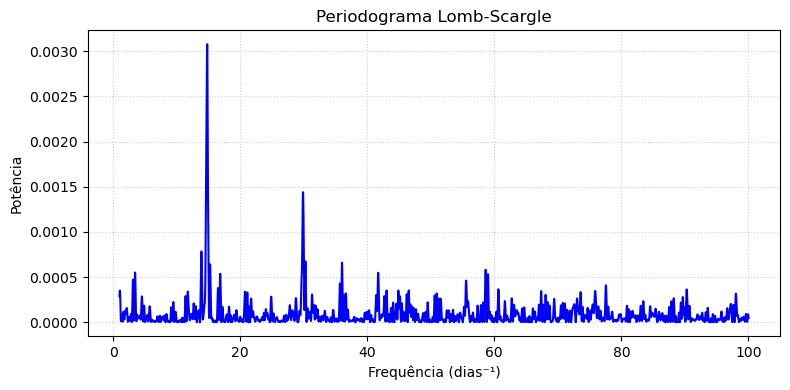

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle

caminho = 'data/ bins 60s/3-10kev/nu30201034002A01_sr.lc'
tabela = Table.read(caminho, hdu=1)

time = np.array(tabela['TIME'])
rate = np.array(tabela['RATE'])
err = np.array(tabela['ERROR']) if 'ERROR' in tabela.colnames else None

mask = (rate > 0) & ~np.isnan(rate)

t_dias = time[mask] / 86400.0
rate_clean = rate[mask] - np.mean(rate[mask]) 

min_p, max_p = 0.01, 1.0
freq_min, freq_max = 1 / max_p, 1 / min_p

ls = LombScargle(t_dias, rate_clean, err[mask] if err is not None else None)
freq, power = ls.autopower(
    minimum_frequency=freq_min, maximum_frequency=freq_max, samples_per_peak=10
)

idx_pico = np.argmax(power)
best_freq = freq[idx_pico]
best_p = 1 / best_freq

p_esperado = 3.90603  
f_esperado = 1 / p_esperado

print(f'Melhor frequência: {best_freq:.4f} dias⁻¹ (P = {best_p:.2f} dias)')
print(f'Frequência esperada: {f_esperado:.4f} dias⁻¹ (P = {p_esperado} dias)')

plt.figure(figsize=(8, 4))
plt.plot(freq, power, 'b-', lw=1.5)
#plt.axvline(
 #   f_esperado,
  #  color='r',
   # ls='--',
   # label=f'Esperado (P = {p_esperado} d)',
#)
#plt.axvline(
 #   best_freq, color='k', ls=':', label=f'Pico (P = {best_p:.2f} d)'
#)
plt.xlabel('Frequência (dias⁻¹)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle')
#plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

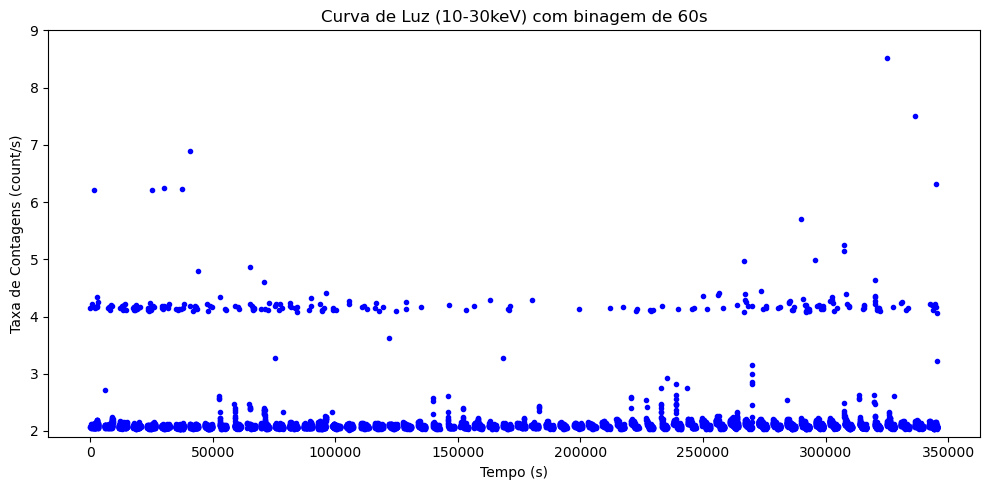

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

caminho = 'data/ bins 60s/10-30kev/nu30201034002A01_sr.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (10-30keV) com binagem de 60s')
plt.ylim(1.9,9.0)


plt.tight_layout()
plt.show()

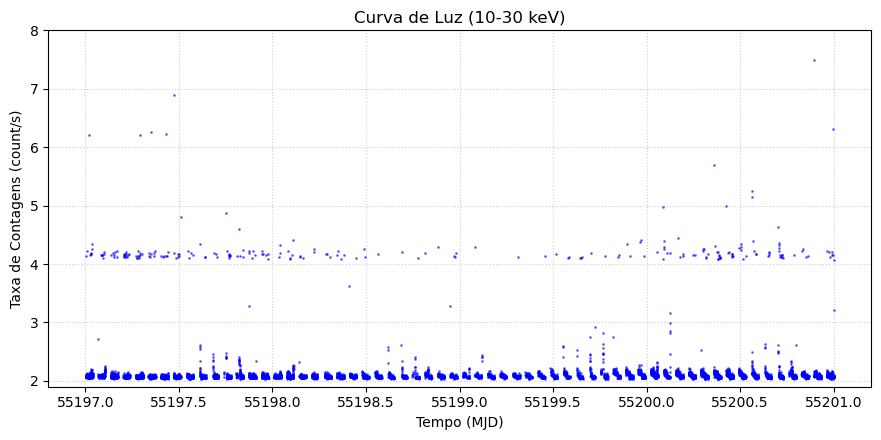

In [18]:
import matplotlib.pyplot as plt
from astropy.table import Table

caminho = 'data/ bins 60s/10-30kev/nu30201034002A01_sr.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

plt.figure(figsize=(9, 4.5))
plt.plot(df['MJD'], df['RATE'], 'b.', alpha=0.5, markersize=2)
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (10-30 keV)')
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.ylim(1.9,8)
plt.show()

Melhor frequência: 14.8297 dias⁻¹ (P = 0.07 dias)
Frequência esperada: 0.2560 dias⁻¹ (P = 3.90603 dias)


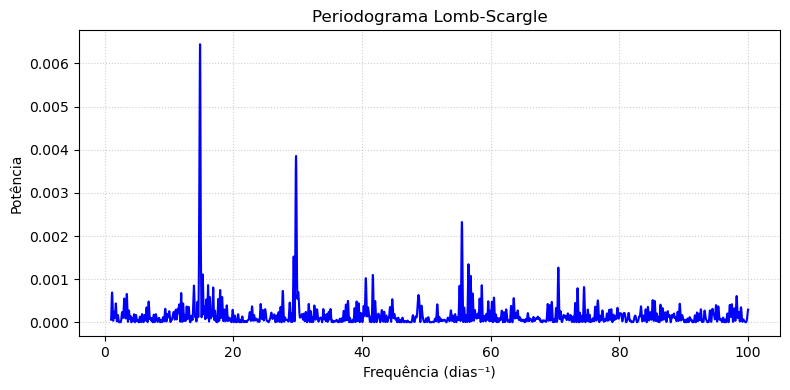

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle

caminho = 'data/ bins 60s/10-30kev/nu30201034002A01_sr.lc'
tabela = Table.read(caminho, hdu=1)

time = np.array(tabela['TIME'])
rate = np.array(tabela['RATE'])
err = np.array(tabela['ERROR']) if 'ERROR' in tabela.colnames else None

mask = (rate > 0) & ~np.isnan(rate)

t_dias = time[mask] / 86400.0
rate_clean = rate[mask] - np.mean(rate[mask]) 

min_p, max_p = 0.01, 1.0
freq_min, freq_max = 1 / max_p, 1 / min_p

ls = LombScargle(t_dias, rate_clean, err[mask] if err is not None else None)
freq, power = ls.autopower(
    minimum_frequency=freq_min, maximum_frequency=freq_max, samples_per_peak=10
)

idx_pico = np.argmax(power)
best_freq = freq[idx_pico]
best_p = 1 / best_freq

p_esperado = 3.90603  
f_esperado = 1 / p_esperado

print(f'Melhor frequência: {best_freq:.4f} dias⁻¹ (P = {best_p:.2f} dias)')
print(f'Frequência esperada: {f_esperado:.4f} dias⁻¹ (P = {p_esperado} dias)')

plt.figure(figsize=(8, 4))
plt.plot(freq, power, 'b-', lw=1.5)
#plt.axvline(
 #   f_esperado,
  #  color='r',
   # ls='--',
   # label=f'Esperado (P = {p_esperado} d)',
#)
#plt.axvline(
 #   best_freq, color='k', ls=':', label=f'Pico (P = {best_p:.2f} d)'
#)
plt.xlabel('Frequência (dias⁻¹)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle')
#plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

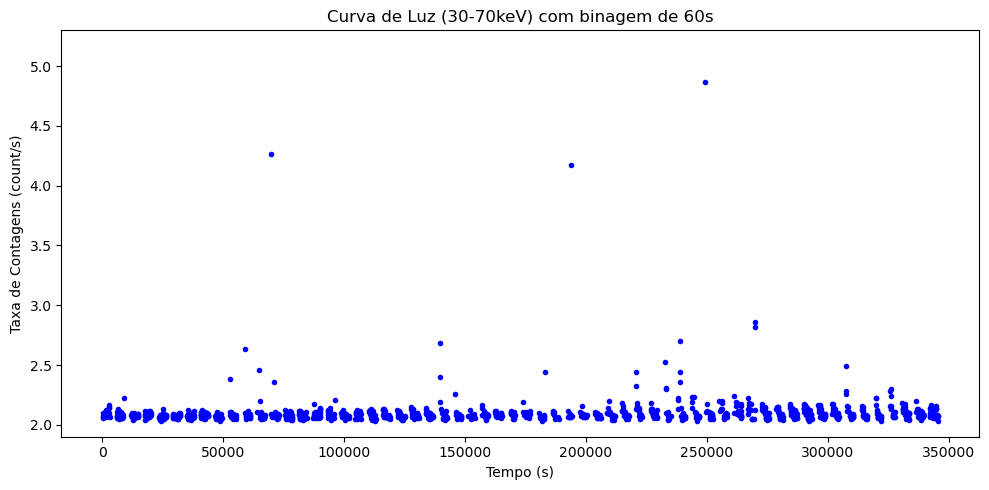

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

caminho = 'data/ bins 60s/30-70kev/nu30201034002A01_sr.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (30-70keV) com binagem de 60s')
plt.ylim(1.9,5.3)


plt.tight_layout()
plt.show()

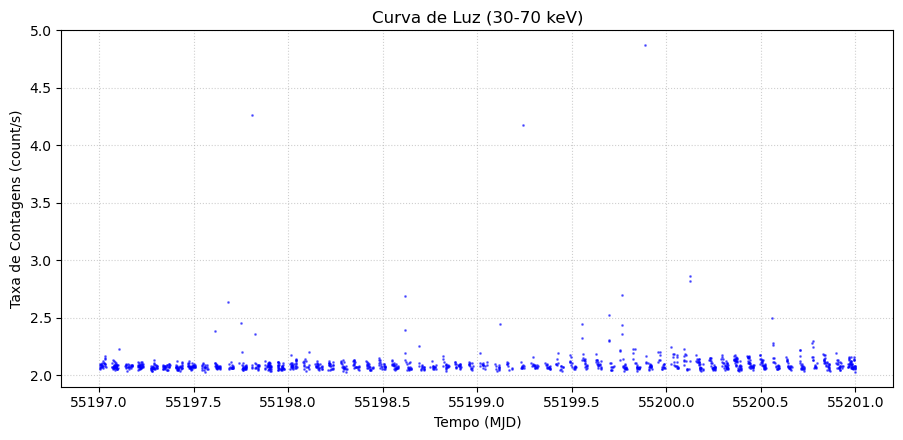

In [20]:
import matplotlib.pyplot as plt
from astropy.table import Table

caminho = 'data/ bins 60s/30-70kev/nu30201034002A01_sr.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

plt.figure(figsize=(9, 4.5))
plt.plot(df['MJD'], df['RATE'], 'b.', alpha=0.5, markersize=2)
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (30-70 keV)')
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.ylim(1.9,5)
plt.show()

Melhor frequência: 14.8433 dias⁻¹ (P = 0.07 dias)
Frequência esperada: 0.2560 dias⁻¹ (P = 3.90603 dias)


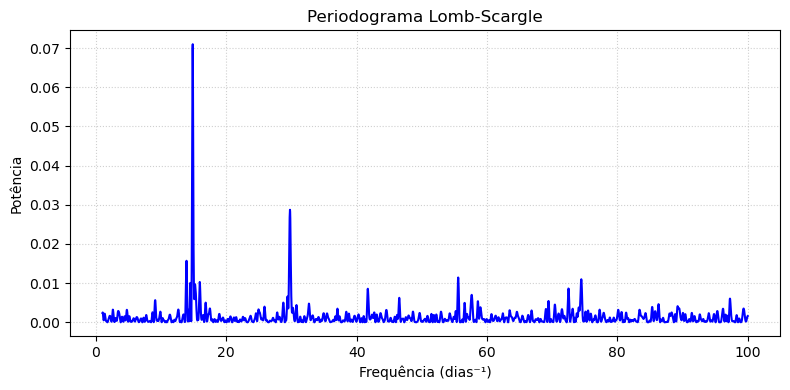

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle

caminho = 'data/ bins 60s/30-70kev/nu30201034002A01_sr.lc'
tabela = Table.read(caminho, hdu=1)

time = np.array(tabela['TIME'])
rate = np.array(tabela['RATE'])
err = np.array(tabela['ERROR']) if 'ERROR' in tabela.colnames else None

mask = (rate > 0) & ~np.isnan(rate)

t_dias = time[mask] / 86400.0
rate_clean = rate[mask] - np.mean(rate[mask]) 

min_p, max_p = 0.01, 1.0
freq_min, freq_max = 1 / max_p, 1 / min_p

ls = LombScargle(t_dias, rate_clean, err[mask] if err is not None else None)
freq, power = ls.autopower(
    minimum_frequency=freq_min, maximum_frequency=freq_max, samples_per_peak=10
)

idx_pico = np.argmax(power)
best_freq = freq[idx_pico]
best_p = 1 / best_freq

p_esperado = 3.90603  
f_esperado = 1 / p_esperado

print(f'Melhor frequência: {best_freq:.4f} dias⁻¹ (P = {best_p:.2f} dias)')
print(f'Frequência esperada: {f_esperado:.4f} dias⁻¹ (P = {p_esperado} dias)')

plt.figure(figsize=(8, 4))
plt.plot(freq, power, 'b-', lw=1.5)
#plt.axvline(
 #   f_esperado,
  #  color='r',
   # ls='--',
   # label=f'Esperado (P = {p_esperado} d)',
#)
#plt.axvline(
 #   best_freq, color='k', ls=':', label=f'Pico (P = {best_p:.2f} d)'
#)
plt.xlabel('Frequência (dias⁻¹)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle')
#plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()